In [ ]:
# TARDIS Visualization Demo

This notebook demonstrates how to:

- Run a TARDIS simulation from a YAML configuration file
- Generate a synthetic spectrum
- Create a Spectral Element Decomposition (SDEC) plot
- Create a Line Interaction Visualization (LIV) plot

The goal is to provide a clear and reproducible way to visualize TARDIS model outputs.

In [1]:
import os
os.environ["TARDIS_DISABLE_WIDGETS"] = "1"

In [2]:
from pathlib import Path
from tardis import run_tardis
from tardis.visualization.tools.sdec_plot import SDECPlotter
from tardis.visualization.tools.liv_plot import LIVPlotter
import matplotlib.pyplot as plt

Initializing tabulator and plotly panel extensions for widgets to work


In [3]:
config_path = Path("../models/minimal.yml")
config_path

WindowsPath('../models/minimal.yml')

In [ ]:
## Model Input Parameters

The simulation is defined using a YAML configuration file.

Some important input parameters include:

### 1. Luminosity Requested
Defines the total luminosity of the supernova model (in erg/s).
This controls the overall brightness of the synthetic spectrum.

### 2. Time Since Explosion
Defines how many days have passed since the explosion.
This affects the temperature structure and spectral features.

### 3. Velocity Structure
Defines the inner and outer velocity boundaries of the ejecta.
This determines the expansion structure of the supernova model.

### 4. Density Profile
Specifies how material density is distributed within the ejecta.
In this example, we use a uniform density profile.

In [5]:
simulation = run_tardis(config_path, show_progress_bars=False)

BokehModel(combine_events=True, render_bundle={'docs_json': {'72cb1aa4-ba1f-47a0-bb0d-7c95727cf34b': {'version…

[py.warnings         ][WARNING]  C:\Users\milanparmar\.conda\envs\tardis_env\Lib\site-packages\tardis\opacities\macro_atom\macroatom_solver.py:624: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

 (warnings.py:110)
Embedding the final state for Jupyter environments


In [ ]:
## Model Input Parameters

The simulation is defined using a YAML configuration file.

Some important input parameters include:

### 1. Luminosity Requested
Defines the total luminosity of the supernova model (in erg/s).
This controls the overall brightness of the synthetic spectrum.

### 2. Time Since Explosion
Defines how many days have passed since the explosion.
This affects the temperature structure and spectral features.

### 3. Velocity Structure
Defines the inner and outer velocity boundaries of the ejecta.
This determines the expansion structure of the supernova model.

### 4. Density Profile
Specifies how material density is distributed within the ejecta.
In this example, we use a uniform density profile.

[tardis.spectrum.formal_integral.formal_integral_solver][WARNING]  The formal integral implementation was not specified. Please run with config option numba or cuda.Defaulting to numba implementation. (formal_integral_solver.py:100)
[tardis.spectrum.formal_integral.formal_integral_solver][WARNING]  The number of interpolate_shells was not specified. The value was set to 80. (formal_integral_solver.py:216)
[py.warnings         ][WARNING]  C:\Users\milanparmar\.conda\envs\tardis_env\Lib\site-packages\astropy\units\format\generic.py:506: UnitsWarning:

'erg/s/Hz' contains multiple slashes, which is discouraged by the FITS standard

 (warnings.py:110)
[py.warnings         ][WARNING]  C:\Users\milanparmar\.conda\envs\tardis_env\Lib\site-packages\astropy\units\format\generic.py:506: UnitsWarning:

'erg/s/Hz' contains multiple slashes, which is discouraged by the FITS standard

 (warnings.py:110)


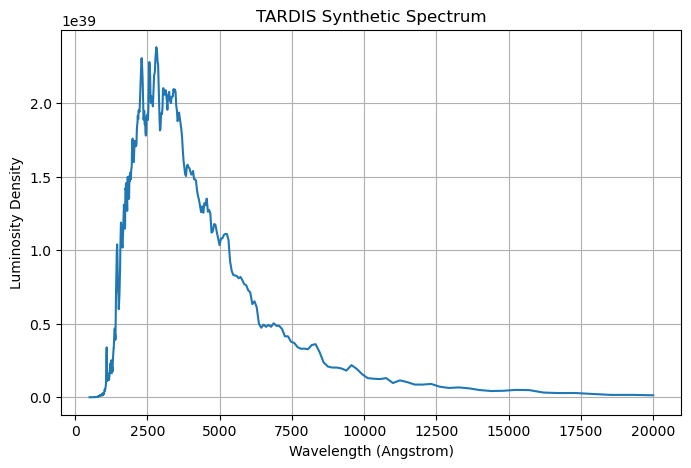

In [6]:
spectrum = simulation.spectrum_solver.spectrum_integrated

plt.figure(figsize=(8,5))
plt.plot(spectrum.wavelength, spectrum.luminosity_density_lambda)
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Luminosity Density")
plt.title("TARDIS Synthetic Spectrum")
plt.grid(True)
plt.show()

In [ ]:
## Spectral Element Decomposition (SDEC)

The SDEC plot shows how different chemical elements contribute to the overall spectrum.

It helps identify which elements are responsible for specific spectral features.

This is useful for understanding the physical origin of spectral lines.

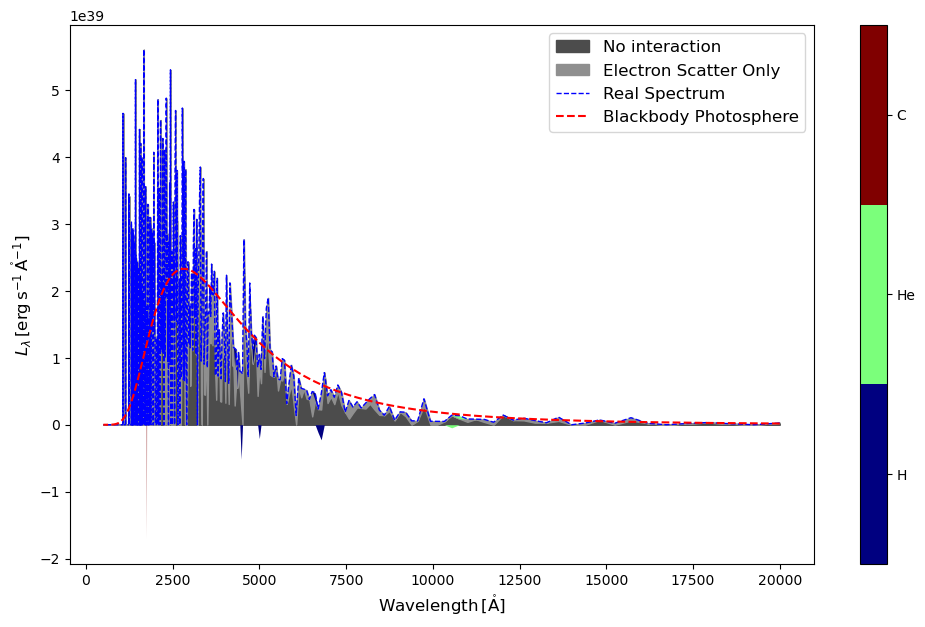

In [7]:
from tardis.visualization.tools.sdec_plot import SDECPlotter

sdec_plotter = SDECPlotter.from_simulation(simulation)

fig = sdec_plotter.generate_plot_mpl(packets_mode="real")

plt.show()

In [ ]:
## Line Interaction Visualization (LIV)

The LIV plot shows how photons interact with spectral lines in the simulation.

It provides insight into line absorption and emission processes within the ejecta.

This helps analyze the radiative transfer behavior inside the supernova model.

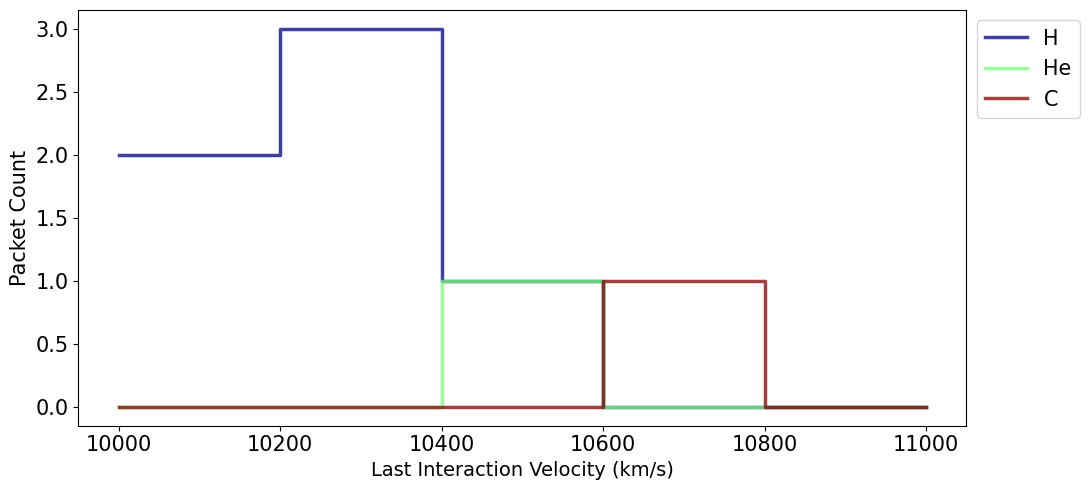

In [8]:
from tardis.visualization.tools.liv_plot import LIVPlotter

liv_plotter = LIVPlotter.from_simulation(simulation)

fig = liv_plotter.generate_plot_mpl()

plt.show()